
# Lab_4: FDM-capacitor

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Potential and Electric field from a capacitor

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).


<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" width="500" height="300" />

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

In [2]:
N = 100
V_i = np.zeros((N,N))
#para tener centrado el capacitor en el espacio creado 100x100
d , l = 20 , 60
delta_d = 1
a, b , c  = 40 , 60 , 20
#entonces los puntos (20-80,a) y (20-80,b) tendran un potencial de 1 y -1
V_i[a,20:80] = 1
V_i[b,20:80] = -1

In [3]:
def Laplace2D(V_i , Nmax, Niter,tol,x,y):

  V = V_i
  i=0
  for iter in range(Niter):
    V_prev = V.copy()
    for i in range(1, Nmax-2):
      for j in range(1,Nmax-2):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
    i+=1
    # Tolerancia
    err = np.max(np.abs(V - V_prev))
    if err < tol:
      break

    V[a,20:80] = 1
    V[b,20:80] = -1

  X, Y = np.meshgrid(x,y)
  Z = V[X,Y]

  return X, Y ,Z


In [4]:
x = np.arange(0,N,1)
y = x
X,Y,Z = Laplace2D(V_i,N,10000,10e-7,x,y)

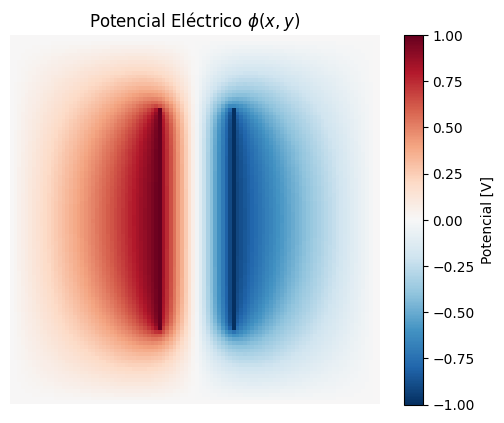

In [5]:
plt.imshow(Z, cmap="RdBu_r", origin="lower")
plt.colorbar(label='Potencial [V]')
plt.title('Potencial Eléctrico $\\phi(x,y)$')
plt.axis('off')
plt.show()


* Compute numerically (use finite difference method) the electric field.
Sea el campo magnetico la divergencia del potencial, derivamos con respecto a x y con respecto a y

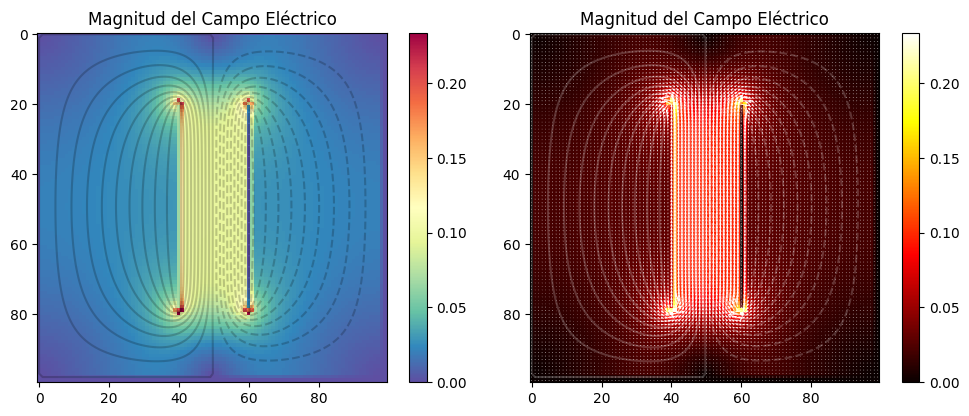

In [23]:
Ex = np.zeros_like(Z)
Ey = np.zeros_like(Z)

for i in range(1, N-1):    #DERIVADAS NUMERICAS
    for j in range(1, N-1):
        Ex[i,j] = -(Z[i+1,j] - Z[i-1,j]) / 2
        Ey[i,j] = -(Z[i,j+1] - Z[i,j-1]) / 2


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im1 = axs[0].imshow(np.sqrt(Ex**2 + Ey**2), cmap="Spectral_r")
fig.colorbar(im1, ax=axs[0])
axs[0].contour(Z, levels=20, colors='black', alpha=0.2)
axs[0].set_title('Magnitud del Campo Eléctrico')

im2 = axs[1].imshow(np.sqrt(Ex**2 + Ey**2), cmap="hot")
fig.colorbar(im2, ax=axs[1])
axs[1].contour(Z, levels=20, colors='white', alpha=0.2)
axs[1].quiver(Ex, Ey, color="white")
axs[1].set_title('Magnitud del Campo Eléctrico')

plt.tight_layout()
plt.show()